In [17]:
#!/usr/bin/env python
# coding: utf-8

# In[91]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
from datasets import load_dataset
import os
from transformers import AutoTokenizer, EarlyStoppingCallback
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from transformers import AutoConfig
from evaluate import load
import matplotlib.pyplot as plt
from torch import nn
import pandas as pd


#### Run Params

train_full_model = True
all_labels = True
model_name = "ProsusAI/finbert"
model_name = "bert-base-uncased"

#####


mypath = "/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/"

#data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data_right_classifications/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_null/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_no_class/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/paragraph_and_sentence_len_4_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/test_read_training_data/paragraph_and_sentence_len_5_min_chunk_len_100_cos_thresh_0.4_nace_level_1_stoxx_with_no_class__cos_sim_04/"
data_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"
data_path = "../../data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"
data_path = mypath + "data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling"

results_path = mypath + "doc_search_and_BERT/Train_BERT/results/results__cos_thresh_045" + os.path.basename(model_name)
results_path = mypath + "doc_search_and_BERT/Train_BERT/results/results__" + os.path.basename(model_name)
if train_full_model: 
    results_path += "__train_full_model" 
else: 
    results_path += "__train_classifier_only" 

if all_labels: 
    results_path += "__all_labels" 
else: 
    results_path += "__some_labels" 
    


os.makedirs(results_path, exist_ok = True)

print(results_path)
print(results_path)
print(results_path)
print(results_path)

from datasets import DatasetDict, Dataset

# Load a custom CSV file
data_files = {"train": os.path.join(data_path, "train_data.csv"), "test": os.path.join(data_path, "test_data.csv"), "validation": os.path.join(data_path, "val_data.csv")}
# Load the CSV files using pandas
train_df = pd.read_csv(data_files["train"])
test_df = pd.read_csv(data_files["test"])
validation_df = pd.read_csv(data_files["validation"])

if not all_labels: 
    #train_df = train_df[train_df["NACE_Code"]!="A"]
    #train_df = train_df[train_df["NACE_Code"]!="J"]
    #train_df = train_df[train_df["NACE_Code"]!="P"]
    #train_df = train_df[train_df["NACE_Code"]!="Q"]
    train_df = train_df[train_df["NACE_Code"]!="R"]
    train_df = train_df[train_df["NACE_Code"]!="S"]
    train_df = train_df[train_df["NACE_Code"]!="T"]
    train_df = train_df.reset_index(drop=True)
    
    #test_df = test_df[test_df["NACE_Code"]!="A"]
    #test_df = test_df[test_df["NACE_Code"]!="J"]
    #test_df = test_df[test_df["NACE_Code"]!="P"]
    #test_df = test_df[test_df["NACE_Code"]!="Q"]
    test_df = test_df[test_df["NACE_Code"]!="R"]
    test_df = test_df[test_df["NACE_Code"]!="S"]
    test_df = test_df[test_df["NACE_Code"]!="T"]
    test_df = test_df.head(100)
    test_df = test_df.reset_index(drop=True)
    
    #validation_df = validation_df[validation_df["NACE_Code"]!="A"]
    #validation_df = validation_df[validation_df["NACE_Code"]!="J"]
    #validation_df = validation_df[validation_df["NACE_Code"]!="P"]
    #validation_df = validation_df[validation_df["NACE_Code"]!="Q"]
    validation_df = validation_df[validation_df["NACE_Code"]!="R"]
    validation_df = validation_df[validation_df["NACE_Code"]!="S"]
    validation_df = validation_df[validation_df["NACE_Code"]!="T"]
    validation_df = validation_df.reset_index(drop=True)

# Load a custom CSV file
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df),
    "validation": Dataset.from_pandas(validation_df)
})

#label_mapping = {char: val for val, char in enumerate(['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U',"NO_CLASS"])}
label_mapping = {char: val for val, char in enumerate(set(train_df["NACE_Code"]))}
dataset = dataset.map(lambda x: {"label": label_mapping[x["NACE_Code"]]})

# Initialize the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize a sample text
sample_text = dataset["train"][0]["text"]
tokens = tokenizer(sample_text, padding="max_length", truncation=True, max_length=128)


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply the tokenizer to the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Inspect tokenized samples
print(tokenized_datasets["train"][0])

labels = dataset["train"]["label"]
class_weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)

if model_name == "ProsusAI/finbert": 
    config = AutoConfig.from_pretrained(model_name, num_labels=len(set(labels)), problem_type="single_label_classification")
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True)
elif model_name == "bert-base-uncased": 
    config = AutoConfig.from_pretrained(model_name, num_labels=len(set(labels)))
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config)

print(model.config)


# In[106]:


hidden = 512
model.classifier = nn.Sequential(
    nn.Linear(config.hidden_size, hidden),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(hidden, config.num_labels),
)


# In[107]:


for param in model.bert.parameters():
    param.requires_grad = train_full_model
    #param.requires_grad = True # Train the wmbeddings as well!

# Keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


# In[108]:


# Define training arguments
training_args = TrainingArguments(
    output_dir=results_path,          # Directory for saving model checkpoints
    evaluation_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=5e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    num_train_epochs=20,              # Number of epochs
    weight_decay=0.01,               # Regularization
    save_total_limit=2,              # Limit checkpoints to save space
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    logging_dir="./logs",            # Directory for logs
    logging_strategy="epoch",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    #fp16=True,                      # Enable mixed precision for faster training
    save_strategy="epoch"
)

print(training_args)


# In[109]:


# Load a metric (F1-score in this case)
metric = load("f1")

# Define a custom compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")


# In[110]:


from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
data_collator


# In[111]:


#device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
device = torch.device("cuda") if torch.backends.mps.is_available() else torch.device("cpu")


# In[112]:


import torch
import torch.nn as nn
from transformers import Trainer

class WeightedCELossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.as_tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]                 # shape [B], dtype long
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits  = outputs.logits                  # [B, C]
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss
        
trainer = WeightedCELossTrainer(
    model=model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,        # Efficient batching
    class_weights=class_weights,   # <— here’s A
    compute_metrics=compute_metrics,     # Custom metric
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,      # stop after 2 evals with no improvement
        early_stopping_threshold=0.0    # optional min improvement; e.g. 1e-4
    )]
)

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/doc_search_and_BERT/Train_BERT/results/results__bert-base-uncased__train_full_model__all_labels
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/doc_search_and_BERT/Train_BERT/results/results__bert-base-uncased__train_full_model__all_labels
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/doc_search_and_BERT/Train_BERT/results/results__bert-base-uncased__train_full_model__all_labels
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/doc_search_and_BERT/Train_BERT/results/results__bert-base-uncased__train_full_model__all_labels


Map:   0%|          | 0/35499 [00:00<?, ? examples/s]

Map:   0%|          | 0/11833 [00:00<?, ? examples/s]

Map:   0%|          | 0/11834 [00:00<?, ? examples/s]

Map:   0%|          | 0/35499 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/11834 [00:00<?, ? examples/s]

{'Evaluation': None, 'Notes': None, 'text': 'the procurement process of raw materials for the mechanical construction seeks from several suppliersr. the company has no policy to buy from any single supplier. the raw materials procured for the companys operation can be classied into types as follows.', 'Score': 0.5356489539904472, 'NACE_Code': 'F', 'label': 7, 'input_ids': [101, 1996, 21423, 2832, 1997, 6315, 4475, 2005, 1996, 6228, 2810, 11014, 2013, 2195, 20141, 2099, 1012, 1996, 2194, 2038, 2053, 3343, 2000, 4965, 2013, 2151, 2309, 17024, 1012, 1996, 6315, 4475, 4013, 19405, 2005, 1996, 2194, 2015, 3169, 2064, 2022, 2465, 6340, 2046, 4127, 2004, 4076, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10",
    "11": "LABEL_11",
    "12": "LABEL_12",
    "13": "LABEL_13",
    "14": "LABEL_14",
    "15": "LABEL_15",
    "16": "LABEL_16",
    "17": "LABEL_17",
    "18": "LABEL_18"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_10": 10,
    "LABEL_11": 11,
    "LABEL_12": 12,
    "LABEL_13": 13,
    "LABEL_14": 14,
    "LABEL_15": 15,
    "LABEL_16": 16,
    "LABEL_

/tmp/ipykernel_3372511/3502933604.py:231: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedCELossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
# Start trainingO
trainer.train()

# Evaluate the model
results = trainer.evaluate()

results_txt = str(results)

print(results)

In [22]:
# Generate predictions
predictions = trainer.predict(tokenized_datasets["test"])
predicted_labels = predictions.predictions.argmax(axis=-1)

# Classification report
print(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

results_txt += str(classification_report(tokenized_datasets["test"]["label"], predicted_labels))

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       413
           1       0.00      0.00      0.00        63
           2       0.00      0.00      0.00       424
           3       0.12      0.03      0.05      1078
           4       0.09      0.03      0.05      1172
           5       0.00      0.00      0.00      1104
           6       0.02      0.94      0.04       255
           7       0.00      0.00      0.00      1087
           8       0.08      0.01      0.02       963
           9       0.00      0.00      0.00        80
          10       0.00      0.00      0.00       222
          11       0.00      0.00      0.00      1091
          12       0.00      0.00      0.00       180
          13       0.00      0.00      0.00       234
          14       0.00      0.00      0.00       612
          15       0.00      0.00      0.00       527
          16       0.00      0.00      0.00      1786
          17       0.00    

/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: Undefin

NameError: name 'results_txt' is not defined

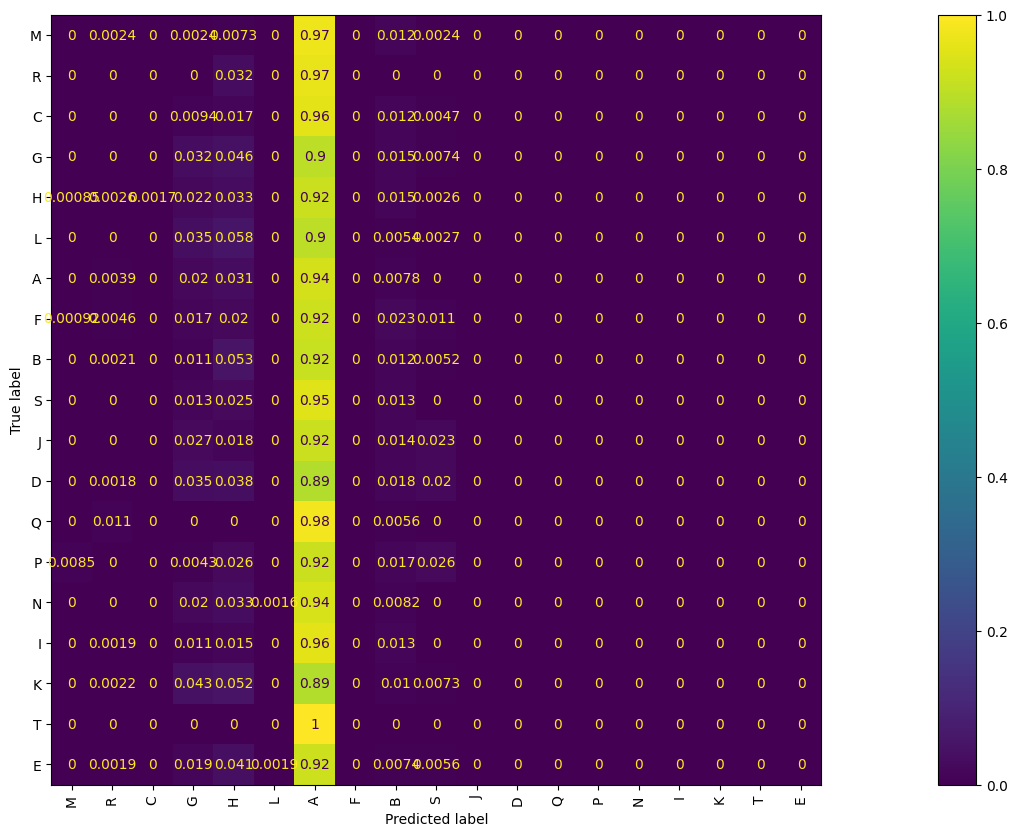

In [24]:
cm = confusion_matrix(tokenized_datasets["test"]["label"], predicted_labels, normalize="true")
alphabet = "ABCDEFGHIJKLMNOPQRSTUVW"
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Label_{alphabet[i]}" for i in range(0, 21)])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_mapping.keys()))
#disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(30, 10))  # <-- set size here
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()

In [ ]:
plt.savefig(results_path + "/conf_matrix.png")

with open(results_path + "/results_txt.txt", "w") as f:
    f.write(results_txt)

logs = pd.DataFrame(trainer.state.log_history)
logs.head()

plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))
logs_epoch = logs.dropna(subset="loss")
eval_loss_epoch = logs.dropna(subset="eval_loss")
plt.plot(logs_epoch["epoch"], logs_epoch["loss"], label="Training Loss")
if "eval_loss" in logs:
    plt.plot(eval_loss_epoch["epoch"], eval_loss_epoch["eval_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.savefig(results_path + "/losses.png")

